## Term Paper - Winter Semester 25/26 Submission

#### **Research Topic: Is Attention All You Need in Low-Resource Settings? An empirical study of self attention integrated with BiLSTM vs Transformers for a low resource language; Swahili.**

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns

In [2]:
holdout_train = pd.read_csv("Swahili_News_Train.csv")
holdout_test = pd.read_csv("Swahili_News_Test.csv")

print(f"Validate train column names: {holdout_train.columns},\nValidate test column names: {holdout_test.columns}")

Validate train column names: Index(['id', 'content', 'category'], dtype='object'),
Validate test column names: Index(['swahili_id', 'content'], dtype='object')


In [3]:
swahili_news = pd.read_csv("SwahiliNewsClassificationDataset.csv")
swahili_news.head()

,id,content,category
0,SW4670,"Bodi ya Utalii Tanzania (TTB) imesema, itafan...",uchumi
1,SW30826,"PENDO FUNDISHA-MBEYA RAIS Dk. John Magufuri, ...",kitaifa
2,SW29725,Mwandishi Wetu -Singida BENKI ya NMB imetoa ms...,uchumi
3,SW20901,"TIMU ya taifa ya Tanzania, Serengeti Boys jan...",michezo
4,SW12560,Na AGATHA CHARLES – DAR ES SALAAM ALIYEKUWA K...,kitaifa


In [4]:
print(
    f"Training set has {swahili_news.shape[0]} rows while validation/developer set has {holdout_train.shape[0]} rows."
    )

Training set has 23268 rows while validation/developer set has 5151 rows.


In [5]:
print(
    f"Categories in training but missing in validation: {set(swahili_news["category"].str.lower().unique()) - set(holdout_train["category"].str.lower().unique())}"
    )

Categories in training but missing in validation: {'uchumi', 'afya'}


In [6]:
print(
    f"Categories in validation but missing in training: {set(holdout_train["category"].str.lower().unique()) - set(swahili_news["category"].str.lower().unique())}"
    )

Categories in validation but missing in training: {'biashara'}


In [7]:
print(
    f"Categories in validation but missing in training: {set(holdout_train["category"].unique()) - set(swahili_news["category"].unique())}"
    )

Categories in validation but missing in training: {'Kitaifa', 'Biashara', 'Burudani', 'Kimataifa'}


In [8]:
print(
    f"Categories is training data: {swahili_news["category"].str.lower().unique()}.\nCategories in validation set: {holdout_train["category"].str.lower().unique()}"
    )

Categories is training data: ['uchumi' 'kitaifa' 'michezo' 'kimataifa' 'burudani' 'afya'].
Categories in validation set: ['kitaifa' 'biashara' 'michezo' 'kimataifa' 'burudani']


In [9]:
set(
    holdout_train["category"].str.lower().unique()
    ) & set(
        swahili_news["category"].str.lower().unique()
        )

{'burudani', 'kimataifa', 'kitaifa', 'michezo'}

In [10]:
swahili_news["category"].value_counts()

category
kitaifa      10242
michezo       6004
burudani      2229
uchumi        2028
kimataifa     1906
afya           859
Name: count, dtype: int64

In [11]:
holdout_train["category"].value_counts()

category
Kitaifa      2000
michezo      1720
Biashara     1360
Kimataifa      54
Burudani       17
Name: count, dtype: int64

<Axes: xlabel='category', ylabel='count'>

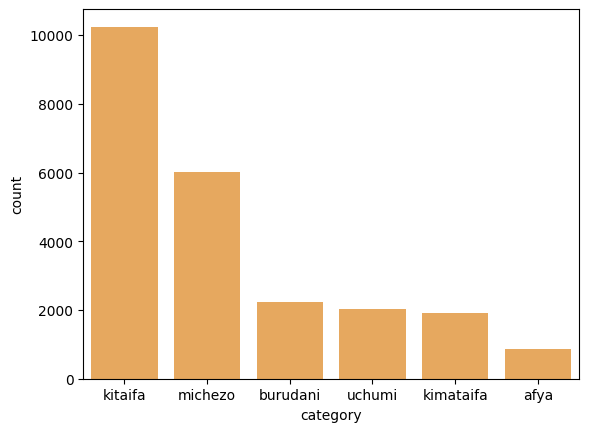

In [12]:
sns.countplot(
    x="category",
    data=swahili_news,
    color="#fdaa48",
    order=swahili_news["category"].value_counts().index
    )

<Axes: xlabel='category', ylabel='count'>

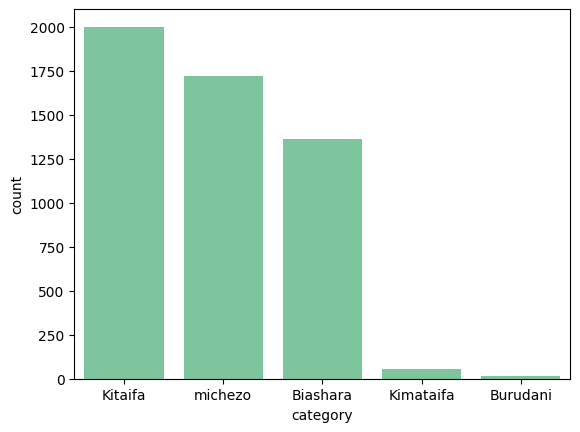

In [13]:
sns.countplot(
    x="category",
    data=holdout_train,
    color="#72d09c",
    order=holdout_train["category"].value_counts().index
    )